# Criteo公开实验：访问与转化

这是项目分析程序的学习入口。核心逻辑在src中，此Notebook读取实际结果并复核关键计算。

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import display, Image
from src.experiment import difference_ci
from src.metrics import gain_curve
from src.utils import read_json
print('项目根目录:', ROOT)

项目根目录: D:\resume\projects\criteo-uplift-analysis


## 1. 文件身份与随机抽样
读来源清单及抽样清单。row_id是原始文件位置，不是公开用户ID；不会被用作模型特征。

In [2]:
display(read_json(ROOT/'data/source_manifest.json'))
display(read_json(ROOT/'data/sample_manifest.json'))

{'publisher': 'Criteo AI Lab',
 'version': 'v2.1',
 'url': 'https://huggingface.co/datasets/criteo/criteo-uplift/resolve/main/criteo-research-uplift-v2.1.csv.gz',
 'file': 'criteo-research-uplift-v2.1.csv.gz',
 'bytes': 311422618,
 'sha256': '2716e1bf0fd157a93b5bf86924d9088419dfbac2022c6cd90030220634f616dc',
 'expected_rows': 13979592,
 'license': 'CC BY-NC-SA 4.0',
 'verified_at': '2026-10-07T10:57:30.419594+00:00'}

{'source_sha256': '2716e1bf0fd157a93b5bf86924d9088419dfbac2022c6cd90030220634f616dc',
 'source_rows': 13979592,
 'sample_size': 3000000,
 'seed': 42,
 'sampling': 'uniform_without_replacement_over_all_verified_source_positions',
 'positions_sha256': 'dd6459a50a9920fb5660969c87fca3aeae23f68b09e0e56d621b088e2b7747ed',
 'split_counts': {'test': 600000, 'train': 1800000, 'validation': 600000},
 'duplicate_anonymized_profiles_retained': 71981,
 'source_treatment_rate': 0.8500001287591226,
 'source_visit_rate': 0.046992000911042324,
 'source_conversion_rate': 0.002916680257907384,
 'prepared_at': '2026-10-07T09:05:17.711801+00:00',
 'parquet_sha256': '1e808ff49777311a7f606ec089a25fdb4cfc5e98c24186473803c7d31e9762fa'}

## 2. 两组发生率和置信区间
随机分组treatment定义处理。exposure是分组后变量，不能据此筛选实验样本。

In [3]:
summary = pd.read_csv(ROOT/'reports/tables/experiment_summary.csv')
display(summary)
display(pd.read_csv(ROOT/'reports/tables/experiment_effect_intervals.csv'))
for r in summary.itertuples():
    lo, hi = difference_ci(r.positive_treatment, r.n_treatment, r.positive_control, r.n_control)
    print(r.outcome, '复核95%率差区间:', lo, hi)

,outcome,outcome_label,n,n_treatment,n_control,positive_treatment,positive_control,rate_treatment,rate_control,ate,relative_lift,ci_lower,ci_upper,p_value,incremental_per_10000,analysis_role
0,visit,访问,3000000,2550075,449925,123523,17054,0.048439,0.037904,0.010535,0.277935,0.009914,0.011149,1.117541e-208,105.348724,预设主指标
1,conversion,转化,3000000,2550075,449925,7795,874,0.003057,0.001943,0.001114,0.573591,0.000965,0.001256,1.017213e-37,11.142269,探索性辅助指标


,outcome,outcome_label,metric,estimate,ci_lower,ci_upper,confidence_level,method,unit,n,n_treatment,n_control
0,visit,访问,rate_treatment,0.048439,0.048176,0.048703,0.95,Wilson,proportion,3000000,2550075,449925
1,visit,访问,rate_control,0.037904,0.037350,0.038466,0.95,Wilson,proportion,3000000,2550075,449925
2,visit,访问,absolute_difference,0.010535,0.009914,0.011149,0.95,Newcombe hybrid score,proportion_difference,3000000,2550075,449925
3,visit,访问,relative_lift,0.277935,0.258035,0.298149,0.95,"log-risk-ratio normal, minus one",relative_change,3000000,2550075,449925
4,conversion,转化,rate_treatment,0.003057,0.002990,0.003125,0.95,Wilson,proportion,3000000,2550075,449925
5,conversion,转化,rate_control,0.001943,0.001818,0.002076,0.95,Wilson,proportion,3000000,2550075,449925
6,conversion,转化,absolute_difference,0.001114,0.000965,0.001256,0.95,Newcombe hybrid score,proportion_difference,3000000,2550075,449925
7,conversion,转化,relative_lift,0.573591,0.467437,0.687424,0.95,"log-risk-ratio normal, minus one",relative_change,3000000,2550075,449925


visit 复核95%率差区间: 0.00991449614307314 0.011148694414740638
conversion 复核95%率差区间: 0.0009653161048238042 0.0012563102535511107


## 3. 平衡和质量
连续SMD与类别总变差的量纲不同，参考线仅作描述。不存在原始分流方案时，不能用四舍五入的85%做正式SRM结论。

,feature,kind,metric,difference,mean_treatment,mean_control,reference_threshold,balanced_descriptively
0,f0,continuous,absolute_SMD,0.007374,19.616870,19.656554,0.1,True
1,f2,continuous,absolute_SMD,0.006498,8.446091,8.448040,0.1,True
2,f7,continuous,absolute_SMD,0.018352,5.105032,5.083181,0.1,True
3,f10,continuous,absolute_SMD,0.012752,5.333794,5.331668,0.1,True
4,f1,categorical,total_variation_distance,0.002657,NaN,NaN,0.1,True
5,f3,categorical,total_variation_distance,0.013151,NaN,NaN,0.1,True
6,f4,categorical,total_variation_distance,0.003127,NaN,NaN,0.1,True
7,f5,categorical,total_variation_distance,0.005481,NaN,NaN,0.1,True
8,f6,categorical,total_variation_distance,0.014260,NaN,NaN,0.1,True
9,f8,categorical,total_variation_distance,0.012657,NaN,NaN,0.1,True


,check,scope,value,passed
0,missing_cells,full_source,0,True
1,nonfinite_features,full_source,0,True
2,nonbinary_labels,full_source,0,True
3,control_exposed,full_source,0,True
4,conversion_without_visit,full_source,0,True
5,source_rows_match,full_source,13979592,True


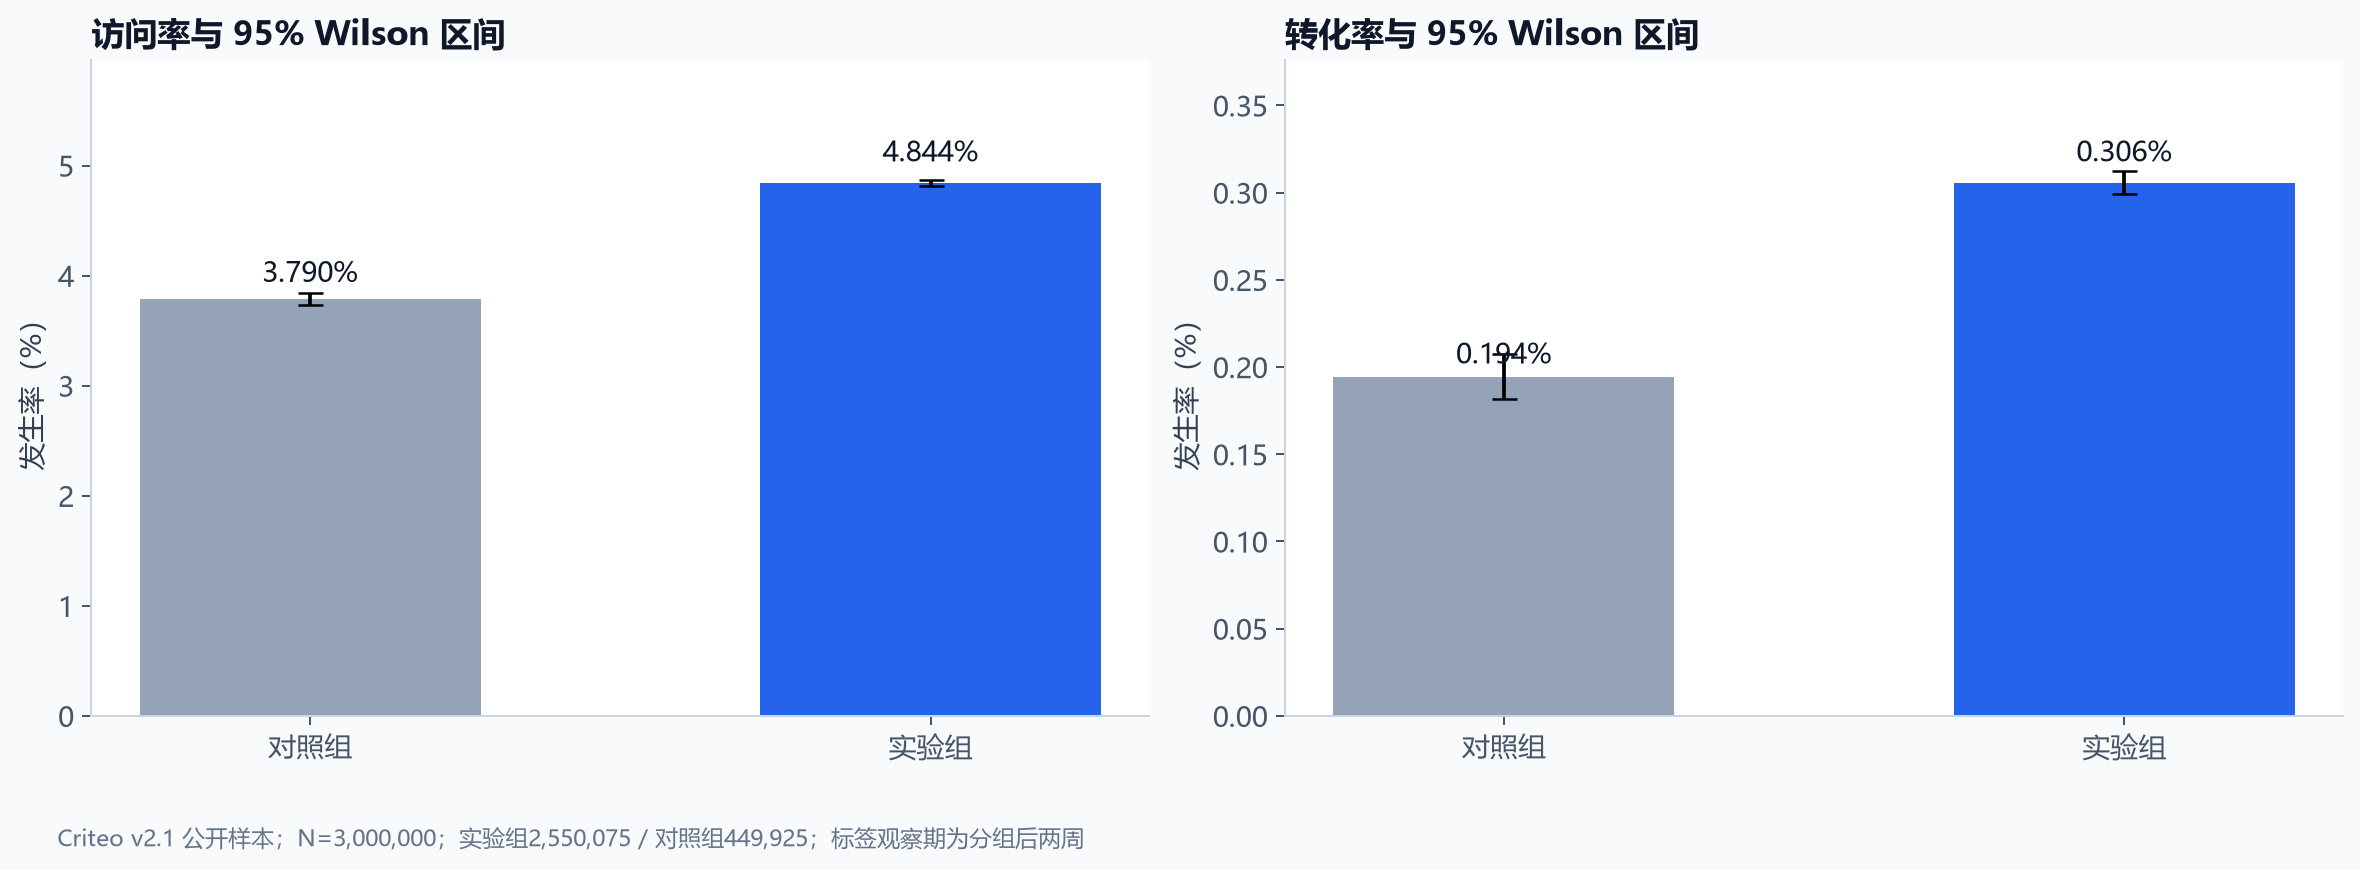

In [4]:
display(pd.read_csv(ROOT/'reports/tables/feature_balance.csv'))
display(pd.read_csv(ROOT/'reports/tables/data_quality_checks.csv'))
display(Image(filename=str(ROOT/'reports/figures/01_experiment_rates.png')))

## 4. 结论边界
公开数据经过非均匀抽样。样本内组间差异可以支持基准研究，不能恢复原活动真实增量，也没有真实ROI。访问为主，转化为探索性辅助指标。